In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [2]:
sns.set_theme(style="whitegrid", font_scale=1.15)
plt.rcParams.update({
    "figure.dpi"      : 130,
    "axes.titlesize"  : 14,
    "axes.titleweight": "bold",
    "axes.labelsize"  : 12,
})

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
df = pd.read_csv("../data/ipl_data.csv")

print(f"Dataset loaded")
print(f"Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"🏏 Matches    : {df['match_id'].nunique():,}")
print(f"🏟️ Venues     : {df['venue'].nunique()}")
print(f"📅 Date range : {df['date'].min()} → {df['date'].max()}")

Dataset loaded
Shape : 278,205 rows × 27 columns
🏏 Matches    : 1,169
🏟️ Venues     : 59
📅 Date range : 2008-04-18 → 2025-06-03


In [4]:
df.head(10)

,match_id,date,venue,batting_team,bowling_team,over,ball,striker,bowler,non_striker,...,wicket_kind,match_winner,winning_outcome,toss_winner,toss_decision,match_referee,tv_umpire,reserve_umpire,umpire_1,umpire_2
0,1426261,2024-04-09,Maharaja Yadavindra Singh International Cricke...,Sunrisers Hyderabad,Punjab Kings,0,1,TM Head,K Rabada,Abhishek Sharma,...,NaN,Sunrisers Hyderabad,2 runs,Punjab Kings,field,V Narayan Kutty,AG Wharf,PM Joshi,Navdeep Singh,NA Patwardhan
1,1426261,2024-04-09,Maharaja Yadavindra Singh International Cricke...,Sunrisers Hyderabad,Punjab Kings,0,2,TM Head,K Rabada,Abhishek Sharma,...,NaN,Sunrisers Hyderabad,2 runs,Punjab Kings,field,V Narayan Kutty,AG Wharf,PM Joshi,Navdeep Singh,NA Patwardhan
2,1426261,2024-04-09,Maharaja Yadavindra Singh International Cricke...,Sunrisers Hyderabad,Punjab Kings,0,3,TM Head,K Rabada,Abhishek Sharma,...,NaN,Sunrisers Hyderabad,2 runs,Punjab Kings,field,V Narayan Kutty,AG Wharf,PM Joshi,Navdeep Singh,NA Patwardhan
3,1426261,2024-04-09,Maharaja Yadavindra Singh International Cricke...,Sunrisers Hyderabad,Punjab Kings,0,4,TM Head,K Rabada,Abhishek Sharma,...,NaN,Sunrisers Hyderabad,2 runs,Punjab Kings,field,V Narayan Kutty,AG Wharf,PM Joshi,Navdeep Singh,NA Patwardhan
4,1426261,2024-04-09,Maharaja Yadavindra Singh International Cricke...,Sunrisers Hyderabad,Punjab Kings,0,5,TM Head,K Rabada,Abhishek Sharma,...,NaN,Sunrisers Hyderabad,2 runs,Punjab Kings,field,V Narayan Kutty,AG Wharf,PM Joshi,Navdeep Singh,NA Patwardhan
5,1426261,2024-04-09,Maharaja Yadavindra Singh International Cricke...,Sunrisers Hyderabad,Punjab Kings,0,6,TM Head,K Rabada,Abhishek Sharma,...,NaN,Sunrisers Hyderabad,2 runs,Punjab Kings,field,V Narayan Kutty,AG Wharf,PM Joshi,Navdeep Singh,NA Patwardhan
6,1426261,2024-04-09,Maharaja Yadavindra Singh International Cricke...,Sunrisers Hyderabad,Punjab Kings,1,1,Abhishek Sharma,Arshdeep Singh,TM Head,...,NaN,Sunrisers Hyderabad,2 runs,Punjab Kings,field,V Narayan Kutty,AG Wharf,PM Joshi,Navdeep Singh,NA Patwardhan
7,1426261,2024-04-09,Maharaja Yadavindra Singh International Cricke...,Sunrisers Hyderabad,Punjab Kings,1,2,TM Head,Arshdeep Singh,Abhishek Sharma,...,NaN,Sunrisers Hyderabad,2 runs,Punjab Kings,field,V Narayan Kutty,AG Wharf,PM Joshi,Navdeep Singh,NA Patwardhan
8,1426261,2024-04-09,Maharaja Yadavindra Singh International Cricke...,Sunrisers Hyderabad,Punjab Kings,1,3,TM Head,Arshdeep Singh,Abhishek Sharma,...,NaN,Sunrisers Hyderabad,2 runs,Punjab Kings,field,V Narayan Kutty,AG Wharf,PM Joshi,Navdeep Singh,NA Patwardhan
9,1426261,2024-04-09,Maharaja Yadavindra Singh International Cricke...,Sunrisers Hyderabad,Punjab Kings,1,4,Abhishek Sharma,Arshdeep Singh,TM Head,...,NaN,Sunrisers Hyderabad,2 runs,Punjab Kings,field,V Narayan Kutty,AG Wharf,PM Joshi,Navdeep Singh,NA Patwardhan


In [5]:
info = pd.DataFrame({
    "dtype"     : df.dtypes,
    "null_count": df.isnull().sum(),
    "null_%"    : (df.isnull().sum() / len(df) * 100).round(2),
    "unique"    : df.nunique()
})
info

,dtype,null_count,null_%,unique
match_id,int64,0,0.00,1169
date,object,0,0.00,885
venue,object,0,0.00,59
batting_team,object,0,0.00,19
bowling_team,object,0,0.00,19
over,int64,0,0.00,20
ball,int64,0,0.00,11
striker,object,0,0.00,703
bowler,object,0,0.00,550
non_striker,object,0,0.00,692


In [6]:
df[["runs_batter","runs_extras","runs_total",
    "innings_score","innings_wickets","is_wicket"]].describe().round(2)

,runs_batter,runs_extras,runs_total,innings_score,innings_wickets,is_wicket
count,278205.00,278205.00,278205.00,278205.00,278205.00,278205.00
mean,1.28,0.07,1.35,77.11,2.46,0.05
std,1.65,0.34,1.64,49.96,2.10,0.22
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,36.00,1.00,0.00
50%,1.00,0.00,1.00,73.00,2.00,0.00
75%,1.00,0.00,1.00,113.00,4.00,0.00
max,6.00,7.00,7.00,287.00,10.00,1.00


In [7]:
# Convert date to datetime
df["date"] = pd.to_datetime(df["date"])

# Extract season year
df["season"] = df["date"].dt.year

# Convert 0-indexed overs to cricket overs (1–20)
df["over_cricket"] = df["over"] + 1

# Fill missing values
df["player_out"]  = df["player_out"].fillna("Not Out")
df["wicket_kind"] = df["wicket_kind"].fillna("Not a Wicket")

print("Cleaning done")
print(f"Seasons covered : {sorted(df['season'].unique())}")

Cleaning done
Seasons covered : [np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


In [8]:
def assign_phase(over):
    if   1 <= over <= 6 : return "Powerplay (1–6)"
    elif 7 <= over <= 15: return "Middle (7–15)"
    else                : return "Death (16–20)"

phase_order = ["Powerplay (1–6)", "Middle (7–15)", "Death (16–20)"]

df["phase"] = df["over_cricket"].apply(assign_phase)
df["phase"] = pd.Categorical(df["phase"], categories=phase_order, ordered=True)

print("Deliveries per phase:")
print(df["phase"].value_counts().reindex(phase_order))

Deliveries per phase:
phase
Powerplay (1–6)     87369
Middle (7–15)      127548
Death (16–20)       63288
Name: count, dtype: int64


## Matches per Season

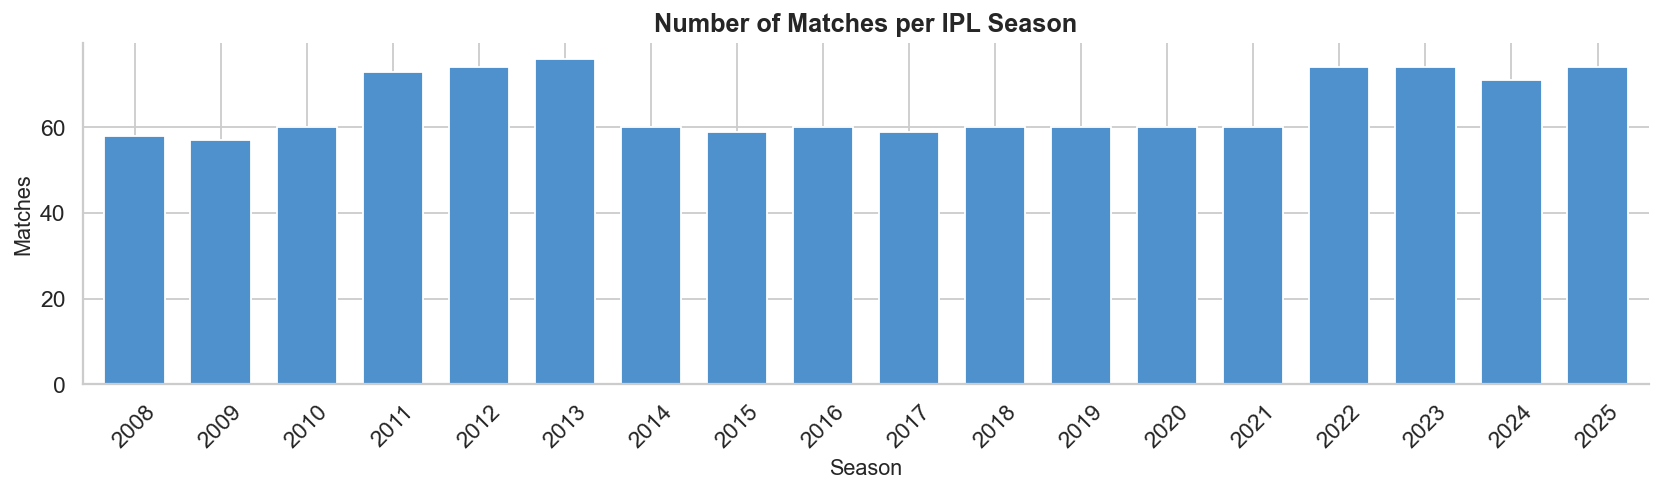


💡 Insight: The gradual increase in matches in recent seasons reflects league expansion, meaning teams must manage player workload and squad depth strategically over longer tournaments.



In [9]:
matches_per_season = df.groupby("season")["match_id"].nunique()

fig, ax = plt.subplots(figsize=(13, 4))
matches_per_season.plot(kind="bar", ax=ax, color="#4F91CD", edgecolor="white", width=0.7)
ax.set_title("Number of Matches per IPL Season")
ax.set_xlabel("Season")
ax.set_ylabel("Matches")
ax.tick_params(axis="x", rotation=45)
sns.despine()
plt.tight_layout()
plt.savefig("../visuals/eda_01_matches_per_season.png", bbox_inches="tight")
plt.show()

print("""
💡 Insight: The gradual increase in matches in recent seasons reflects league expansion, meaning teams must manage player workload and squad depth strategically over longer tournaments.
""")

## Runs Distribtuion

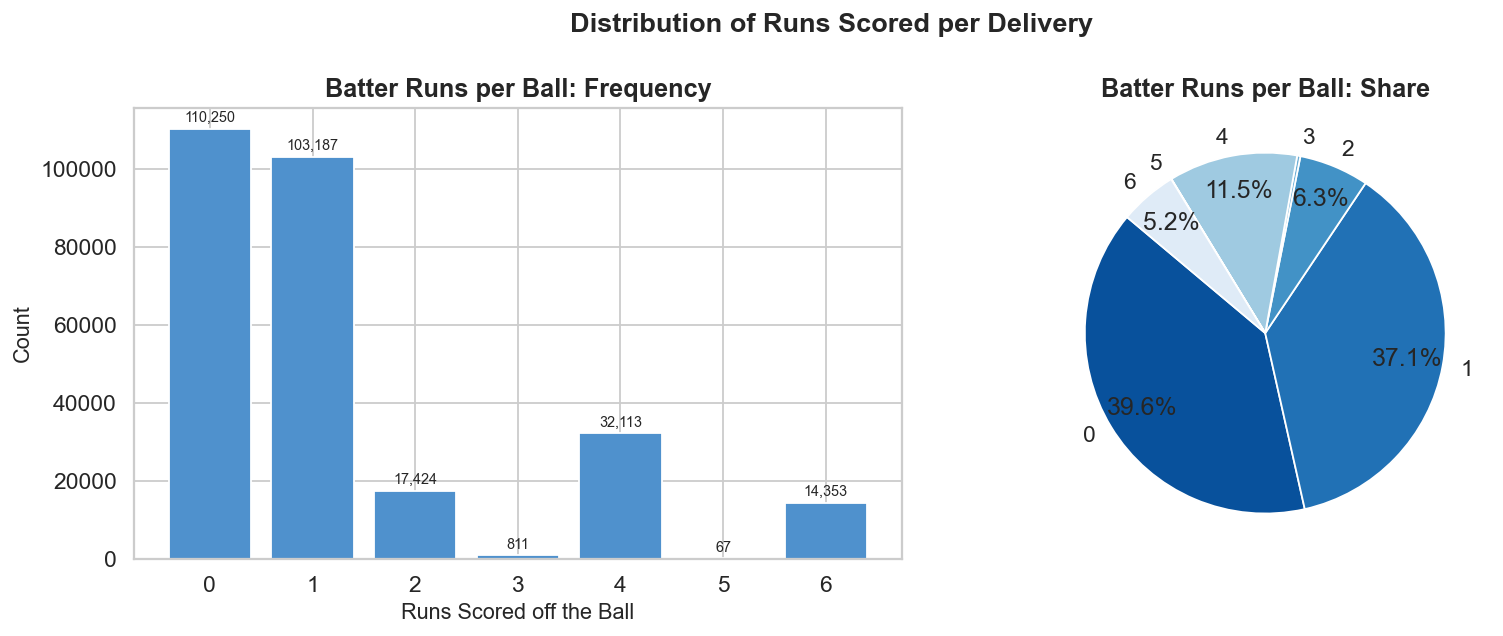


💡 Insight: With dot balls (39.6%) and singles (37.1%) dominating deliveries, successful T20 batting relies on minimising dot balls through strike rotation while capitalising on boundary opportunities.



In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Count of each run value
run_counts = df["runs_batter"].value_counts().sort_index()
axes[0].bar(run_counts.index, run_counts.values, 
            color="#4F91CD", edgecolor="white")
axes[0].set_title("Batter Runs per Ball: Frequency")
axes[0].set_xlabel("Runs Scored off the Ball")
axes[0].set_ylabel("Count")
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1000,
                 f"{bar.get_height():,.0f}",
                 ha="center", va="bottom", fontsize=8)

# Pie chart
axes[1].pie(
    run_counts.values,
    labels=run_counts.index,
    autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
    startangle=140,
    pctdistance=0.8,
    colors=sns.color_palette("Blues_r", len(run_counts))
)
axes[1].set_title("Batter Runs per Ball: Share")

plt.suptitle("Distribution of Runs Scored per Delivery", 
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../visuals/eda_02_runs_distribution.png", bbox_inches="tight")
plt.show()

print("""
💡 Insight: With dot balls (39.6%) and singles (37.1%) dominating deliveries, successful T20 batting relies on minimising dot balls through strike rotation while capitalising on boundary opportunities.
""")

## Scoring Trends over Season

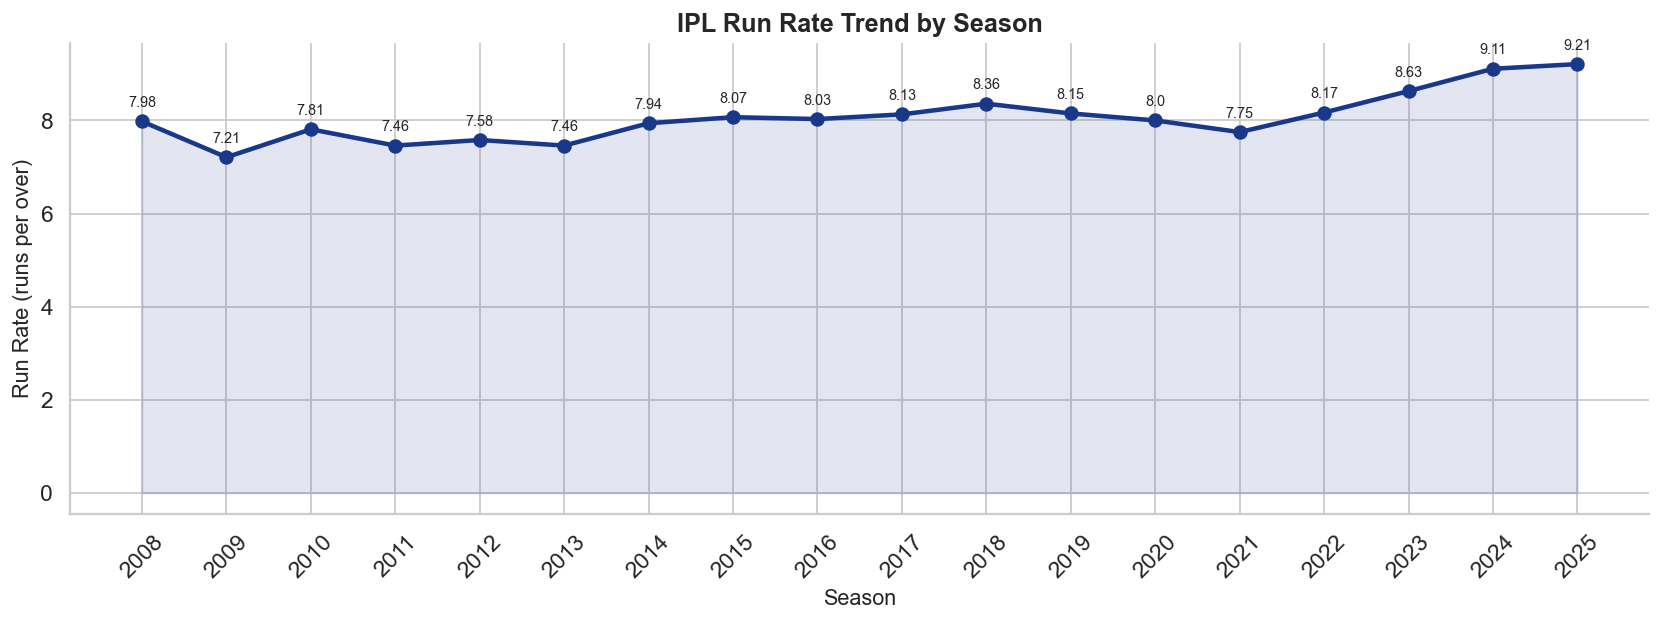


💡 Insight: The steady rise in run rates over the years suggests teams are adopting more aggressive batting strategies, prioritizing power hitting and higher intent throughout the innings.



In [11]:
season_runs = (
    df.groupby("season")
      .agg(total_runs=("runs_total","sum"),
           total_balls=("runs_total","count"))
      .assign(run_rate=lambda x: (x["total_runs"]/x["total_balls"]*6).round(2))
      .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(season_runs["season"], season_runs["run_rate"],
        marker="o", linewidth=2.5, color="#19388A", markersize=7)
ax.fill_between(season_runs["season"], season_runs["run_rate"],
                alpha=0.12, color="#19388A")
for _, row in season_runs.iterrows():
    ax.annotate(f"{row['run_rate']}", 
                xy=(row["season"], row["run_rate"]),
                xytext=(0, 8), textcoords="offset points",
                ha="center", fontsize=8)
ax.set_title("IPL Run Rate Trend by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Run Rate (runs per over)")
ax.set_xticks(season_runs["season"])
ax.tick_params(axis="x", rotation=45)
sns.despine()
plt.tight_layout()
plt.savefig("../visuals/eda_03_run_rate_trend.png", bbox_inches="tight")
plt.show()

print("""
💡 Insight: The steady rise in run rates over the years suggests teams are adopting more aggressive batting strategies, prioritizing power hitting and higher intent throughout the innings.
""")

## Wicket Types

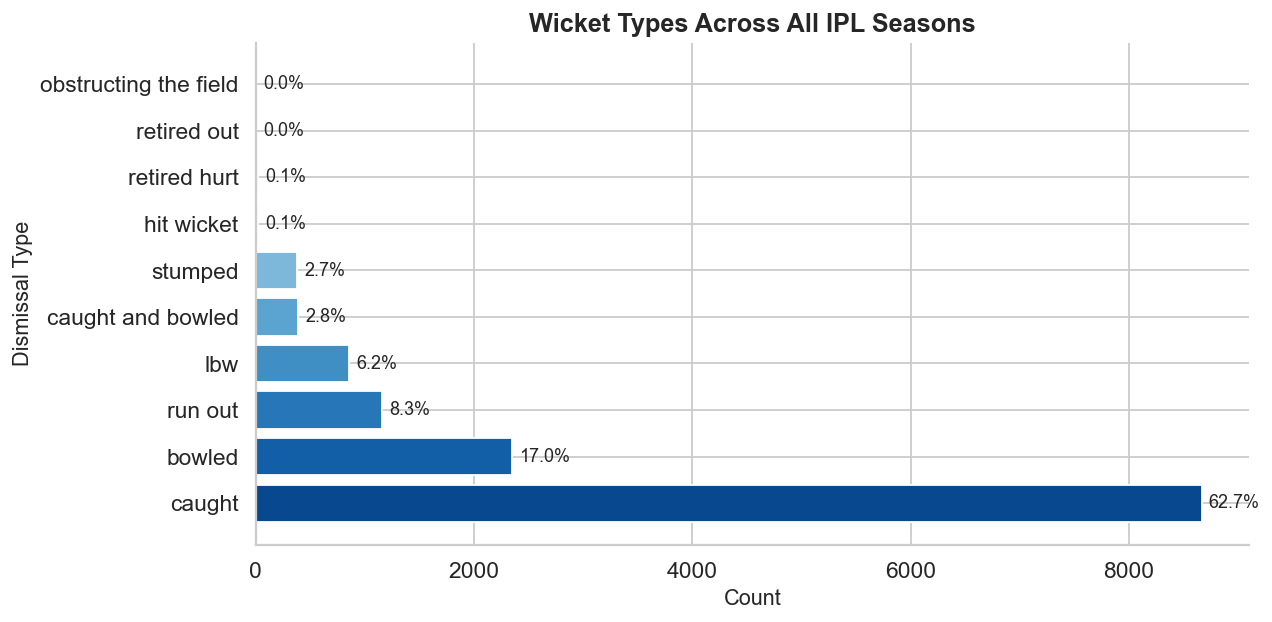


💡 Insight: Since caught dismissals dominate, bowlers increasingly rely on inducing aerial shots through variations and field placements designed to force risky boundary attempts.



In [12]:
wicket_df = df[df["is_wicket"] == 1].copy()

wicket_types = (wicket_df["wicket_kind"]
                .value_counts()
                .reset_index())

wicket_types.columns = ["kind", "count"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(wicket_types["kind"], 
               wicket_types["count"],
               color=sns.color_palette("Blues_r", len(wicket_types)),
               edgecolor="white")

wicket_types["pct"] = (wicket_types["count"] / wicket_types["count"].sum() * 100).round(1)

ax.bar_label(
    bars,
    labels=[f"{p:.1f}%" for p in wicket_types["pct"]],
    padding=4,
    fontsize=10
)
ax.set_title("Wicket Types Across All IPL Seasons")
ax.set_xlabel("Count")
ax.set_ylabel("Dismissal Type")
sns.despine()
plt.tight_layout()
plt.savefig("../visuals/eda_04_wicket_types.png", bbox_inches="tight")
plt.show()

print("""
💡 Insight: Since caught dismissals dominate, bowlers increasingly rely on inducing aerial shots through variations and field placements designed to force risky boundary attempts.
""")

## Toss Impact

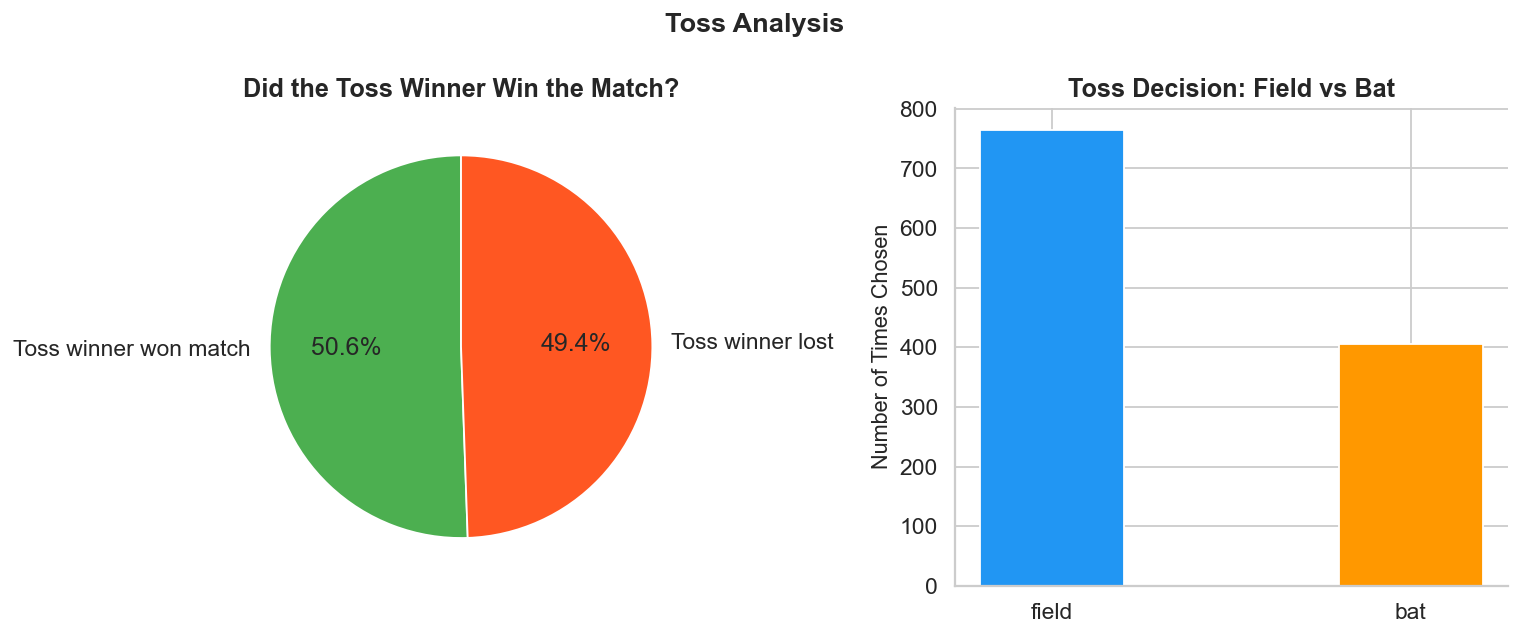


💡 Insight: Despite teams choosing to field first more often, the nearly 50–50 win split shows that the toss advantage is limited, emphasising that in-game tactics and execution matter more than the toss outcome.



In [13]:
toss_df = df.drop_duplicates("match_id")[["match_id","toss_winner","toss_decision","match_winner"]].copy()
toss_df["toss_win_match_win"] = toss_df["toss_winner"] == toss_df["match_winner"]

toss_impact = toss_df["toss_win_match_win"].value_counts()
toss_decision = toss_df["toss_decision"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(toss_impact.values, 
            labels=["Toss winner won match","Toss winner lost"],
            autopct="%1.1f%%", startangle=90,
            colors=["#4CAF50","#FF5722"])
axes[0].set_title("Did the Toss Winner Win the Match?")

axes[1].bar(toss_decision.index, toss_decision.values,
            color=["#2196F3","#FF9800"], width=0.4, edgecolor="white")
axes[1].set_title("Toss Decision: Field vs Bat")
axes[1].set_ylabel("Number of Times Chosen")
sns.despine(ax=axes[1])

plt.suptitle("Toss Analysis", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../visuals/eda_05_toss_analysis.png", bbox_inches="tight")
plt.show()

print("""
💡 Insight: Despite teams choosing to field first more often, the nearly 50–50 win split shows that the toss advantage is limited, emphasising that in-game tactics and execution matter more than the toss outcome.
""")

## Phase Summary

In [14]:
PHASE_PALETTE = {
    "Powerplay (1–6)" : "#059bf5",
    "Middle (7–15)"   : "#f4d474",
    "Death (16–20)"   : "#0554bb",
}

phase_summary = (
    df.groupby("phase", observed=True)
      .agg(
          total_runs    = ("runs_total",  "sum"),
          total_balls   = ("runs_total",  "count"),
          total_wickets = ("is_wicket",   "sum"),
          sixes         = ("runs_batter", lambda x: (x==6).sum()),
          fours         = ("runs_batter", lambda x: (x==4).sum()),
          dot_balls     = ("runs_batter", lambda x: (x==0).sum()),
      )
      .assign(
          run_rate     = lambda x: (x["total_runs"]/x["total_balls"]*6).round(2),
          wicket_rate  = lambda x: (x["total_wickets"]/x["total_balls"]*6).round(3),
          dot_ball_pct = lambda x: (x["dot_balls"]/x["total_balls"]*100).round(1),
          boundary_pct = lambda x: ((x["sixes"]+x["fours"])/x["total_balls"]*100).round(1),
      )
      .reset_index()
)

phase_summary

,phase,total_runs,total_balls,total_wickets,sixes,fours,dot_balls,run_rate,wicket_rate,dot_ball_pct,boundary_pct
0,Powerplay (1–6),111611,87369,3376,3328,13477,43900,7.66,0.232,50.2,19.2
1,Middle (7–15),162249,127548,5347,5906,11388,45009,7.63,0.252,35.3,13.6
2,Death (16–20),100423,63288,5100,5119,7248,21341,9.52,0.484,33.7,19.5


## Phase Comparison Charts

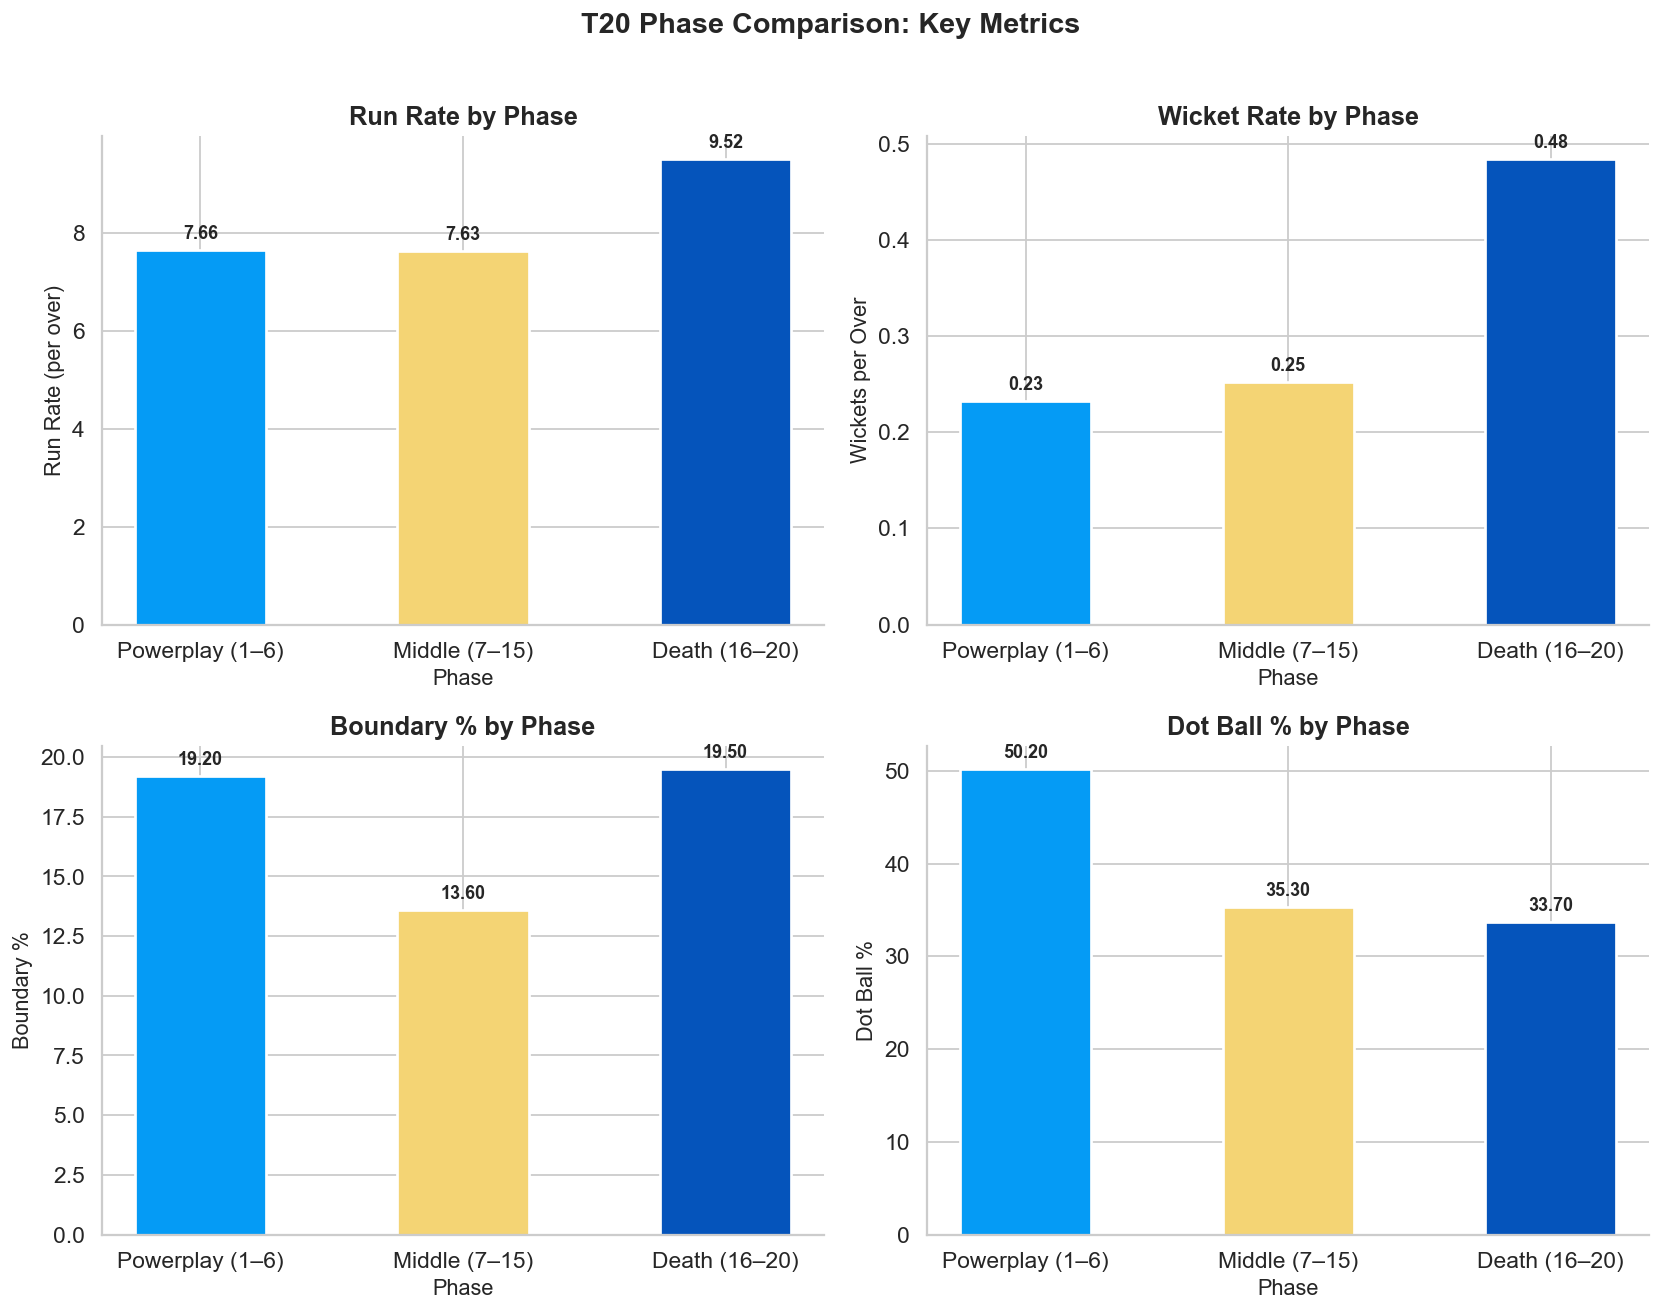


💡 Insight:
   Death Overs have the highest run rate AND highest wicket rate, the ultimate high-risk, high-reward phase. The Middle Overs show the highest dot ball % as bowlers build pressure and batsmen consolidate. Powerplay has the best boundary % alongside Death Overs, showing batsmen attack when fielding restrictions are on.



In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
metrics = [
    ("run_rate",     "Run Rate (per over)",      "Run Rate by Phase"),
    ("wicket_rate",  "Wickets per Over",         "Wicket Rate by Phase"),
    ("boundary_pct", "Boundary %",               "Boundary % by Phase"),
    ("dot_ball_pct", "Dot Ball %",               "Dot Ball % by Phase"),
]

for ax, (col, ylabel, title) in zip(axes.flatten(), metrics):
    bars = ax.bar(
        phase_summary["phase"],
        phase_summary[col],
        color=[PHASE_PALETTE[p] for p in phase_summary["phase"]],
        width=0.5, edgecolor="white", linewidth=1.5
    )
    ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=10, fontweight="bold")
    ax.set_title(title)
    ax.set_xlabel("Phase")
    ax.set_ylabel(ylabel)
    sns.despine(ax=ax)

plt.suptitle("T20 Phase Comparison: Key Metrics", 
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../visuals/eda_06_phase_comparison.png", bbox_inches="tight")
plt.show()

print("""
💡 Insight:
   Death Overs have the highest run rate AND highest wicket rate, the ultimate high-risk, high-reward phase. The Middle Overs show the highest dot ball % as bowlers build pressure and batsmen consolidate. Powerplay has the best boundary % alongside Death Overs, showing batsmen attack when fielding restrictions are on.
""")